In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [2]:
data_path = os.path.join(*Path.cwd().parts[:-1],"data")

**Read in data from csv files**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
drive_data_path = '/content/drive/MyDrive/data'
if os.path.exists(drive_data_path):
    print(os.listdir(drive_data_path))
else:
    print(f"The directory {drive_data_path} does not exist. Please check the path.")

['resampled_2023-01-31_2023-02-24.csv', 'resampled_2023-02-25_2023-03-24.csv', 'resampled_2023-03-25_2023-04-14.csv']


In [5]:
df = pd.DataFrame()
for file in os.listdir(drive_data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(drive_data_path, file)
        temp_df = pd.read_csv(file_path)
        df = pd.concat([df, temp_df], ignore_index=True)
len(df)

4440384

In [6]:
df.head(10)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,2023-01-31 14:00:01,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,2023-01-31 14:00:02,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,2023-01-31 14:00:03,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,2023-01-31 14:00:04,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,2023-01-31 14:00:05,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250
5,2023-01-31 14:00:06,0.000205,0.000166,0.000149,19.791374,19.863214,19.958219,19.611355,19.782754,19.910986,19.686506,19.866983,19.779079,19.822659,20.084014,20.555750,56.515500
6,2023-01-31 14:00:07,0.000207,0.000166,0.000149,19.791391,19.863192,19.958266,19.611362,19.782839,19.910973,19.686427,19.866940,19.779043,19.822784,20.084038,20.554000,56.531250
7,2023-01-31 14:00:08,0.000204,0.000166,0.000149,19.791472,19.863189,19.958201,19.611344,19.782866,19.910877,19.686598,19.866845,19.779098,19.822806,20.084124,20.555750,56.514750
8,2023-01-31 14:00:09,0.000206,0.000166,0.000148,19.791444,19.863215,19.958139,19.611246,19.782896,19.910850,19.686901,19.866846,19.779024,19.822787,20.084177,20.551750,56.517125
9,2023-01-31 14:00:10,0.000205,0.000166,0.000149,19.791392,19.863227,19.958176,19.611274,19.782966,19.910889,19.687056,19.866805,19.778983,19.822764,20.084140,20.552250,56.520000


Convert date to timestamp.

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')
df['Date'] = df['Date'].astype('int64')//10**6

In [8]:
df.head(5)

,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C],Altitude [m]
0,1675173601000,0.000206,0.000166,0.000148,19.791454,19.863238,19.958212,19.611312,19.782525,19.910947,19.686221,19.866912,19.779195,19.822539,20.083956,20.553056,56.501111
1,1675173602000,0.000206,0.000166,0.000149,19.791452,19.863260,19.958182,19.611313,19.782551,19.910995,19.686290,19.866992,19.779090,19.822577,20.084072,20.560000,56.505000
2,1675173603000,0.000205,0.000166,0.000149,19.791477,19.863239,19.958230,19.611286,19.782511,19.910869,19.686390,19.867029,19.779148,19.822605,20.084086,20.553500,56.512875
3,1675173604000,0.000206,0.000166,0.000148,19.791416,19.863226,19.958226,19.611257,19.782615,19.910896,19.686423,19.866973,19.779131,19.822622,20.084077,20.559625,56.511875
4,1675173605000,0.000207,0.000166,0.000149,19.791399,19.863232,19.958224,19.611407,19.782624,19.910894,19.686496,19.866928,19.779156,19.822597,20.084086,20.556125,56.509250


In [9]:
df = df.sort_values('Date').reset_index(drop=True)

In [10]:
import matplotlib.pyplot as plt

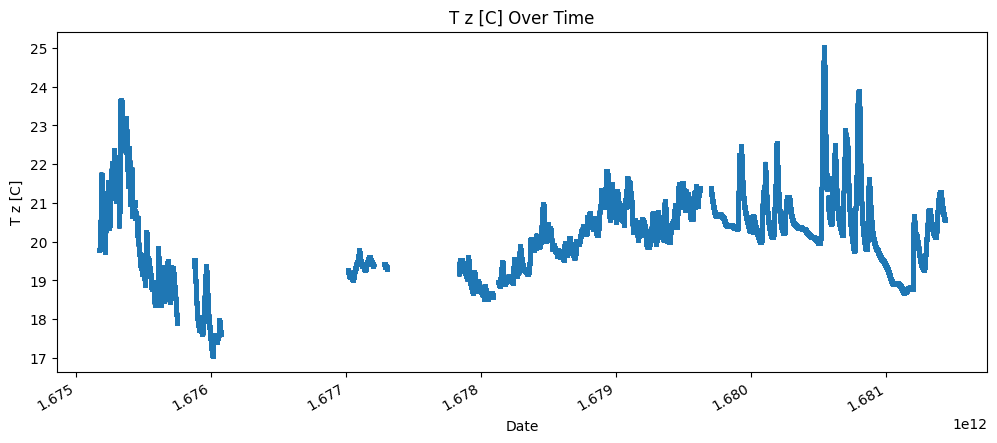

In [11]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T z [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T z [C]")
plt.title("T z [C] Over Time")
plt.gcf().autofmt_xdate()
plt.show()

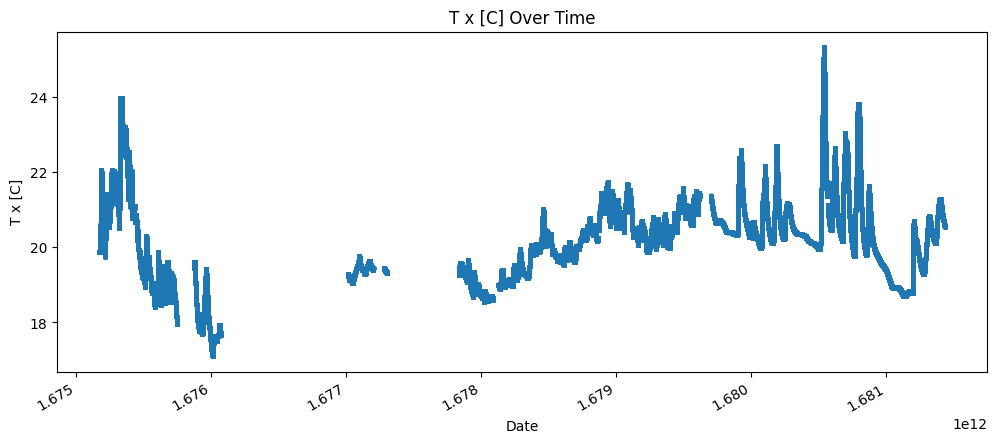

In [12]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T x [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T x [C]")
plt.title("T x [C] Over Time")
plt.gcf().autofmt_xdate()
plt.show()

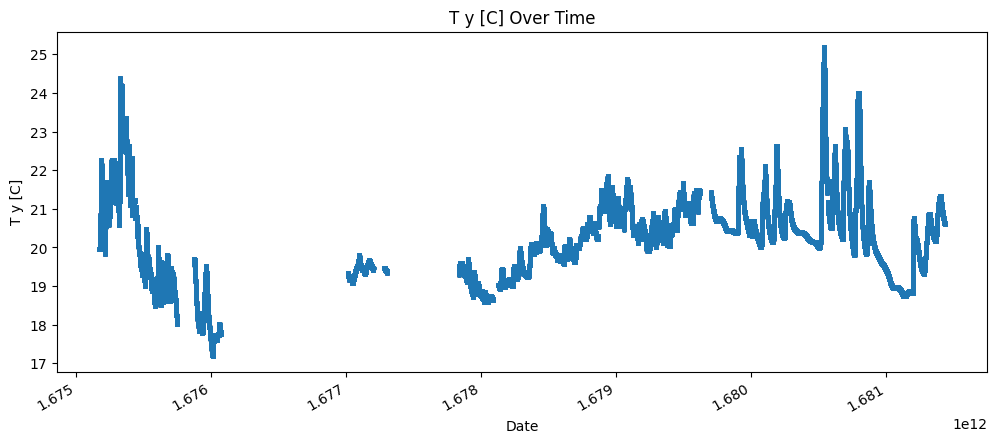

In [13]:
plt.figure(figsize=(12, 5))
plt.scatter(df['Date'], df['T y [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T y [C]")
plt.title("T y [C] Over Time")
plt.gcf().autofmt_xdate()
plt.show()

Determine chunks of data that are uninterrupted.

In [14]:
times = df['Date'].values
best_start, best_end = 0, 0
last_idx = 0
for idx in range(1, len(times)):
    # Corrected condition: 1 second = 1000 milliseconds
    if times[idx] - times[idx - 1] > 1000:
        if idx - last_idx > best_end - best_start:
            best_start, best_end = last_idx, idx
            print(f'New longest run len: {best_end - best_start}')
        last_idx = idx
if len(times) - last_idx > best_end - best_start:
    best_start, best_end = last_idx, len(times)
    print(f'New longest run len: {best_end - best_start}')
uninterrupted_df = df[best_start:best_end]

New longest run len: 269
New longest run len: 4334
New longest run len: 7491
New longest run len: 14438
New longest run len: 17837
New longest run len: 70368
New longest run len: 70795
New longest run len: 90599
New longest run len: 252000
New longest run len: 739720
New longest run len: 746265


In [15]:
uninterrupted_df.drop(columns='Altitude [m]', inplace=True)
uninterrupted_df.head(10)

/tmp/ipykernel_4237/2489916438.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uninterrupted_df.drop(columns='Altitude [m]', inplace=True)


,Date,z [m/s2],x [m/s2],y [m/s2],T z [C],T x [C],T y [C],bottom x1 side [C],x sensor face [C],y sensor face [C],bottom x2 side [C],x elect face [C],y ACQ face [C],top [C],inside air [C],external [C]
1967042,1678873335000,-0.000255,0.000015,0.000027,20.343941,20.452242,20.536662,20.454394,20.840455,21.149750,20.576104,20.980258,20.775696,21.235692,21.021573,20.779997
1967043,1678873336000,-0.000258,0.000015,0.000026,20.344488,20.452119,20.536670,20.454457,20.839291,21.149834,20.576155,20.980214,20.775706,21.235638,21.021625,20.784550
1967044,1678873337000,-0.000258,0.000015,0.000026,20.344734,20.452174,20.536654,20.454648,20.838908,21.149494,20.576266,20.979903,20.775798,21.234698,21.021522,20.789950
1967045,1678873338000,-0.000257,0.000015,0.000026,20.344861,20.452265,20.536711,20.454957,20.838893,21.149110,20.576554,20.979604,20.775955,21.233754,21.021452,20.790000
1967046,1678873339000,-0.000258,0.000014,0.000026,20.344875,20.452364,20.536803,20.455168,20.838885,21.148781,20.576778,20.979453,20.775926,21.232783,21.021507,20.790000
1967047,1678873340000,-0.000256,0.000014,0.000026,20.344939,20.452622,20.536942,20.455435,20.839091,21.148548,20.577267,20.979315,20.775972,21.231861,21.021581,20.787250
1967048,1678873341000,-0.000257,0.000014,0.000027,20.345094,20.452741,20.537126,20.455811,20.839236,21.148320,20.577427,20.979191,20.776113,21.230930,21.021564,20.788750
1967049,1678873342000,-0.000258,0.000015,0.000026,20.345158,20.452818,20.537104,20.456032,20.839469,21.147980,20.577619,20.978906,20.776156,21.230071,21.021545,20.792625
1967050,1678873343000,-0.000257,0.000014,0.000027,20.345339,20.452928,20.537181,20.456352,20.839468,21.147686,20.577954,20.978667,20.776228,21.229101,21.021564,20.801875
1967051,1678873344000,-0.000258,0.000014,0.000026,20.345431,20.453102,20.537346,20.456736,20.839564,21.147560,20.578284,20.978576,20.776275,21.228209,21.021675,20.807750


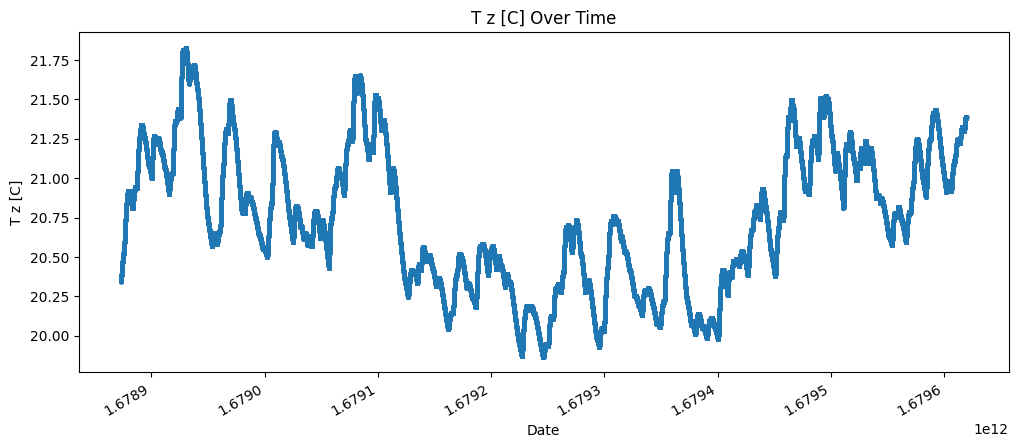

In [16]:
plt.figure(figsize=(12, 5))
plt.scatter(uninterrupted_df['Date'], uninterrupted_df['T z [C]'], alpha=0.3, s=5)
plt.xlabel("Date")
plt.ylabel("T z [C]")
plt.title("T z [C] Over Time")
plt.gcf().autofmt_xdate()
plt.show()

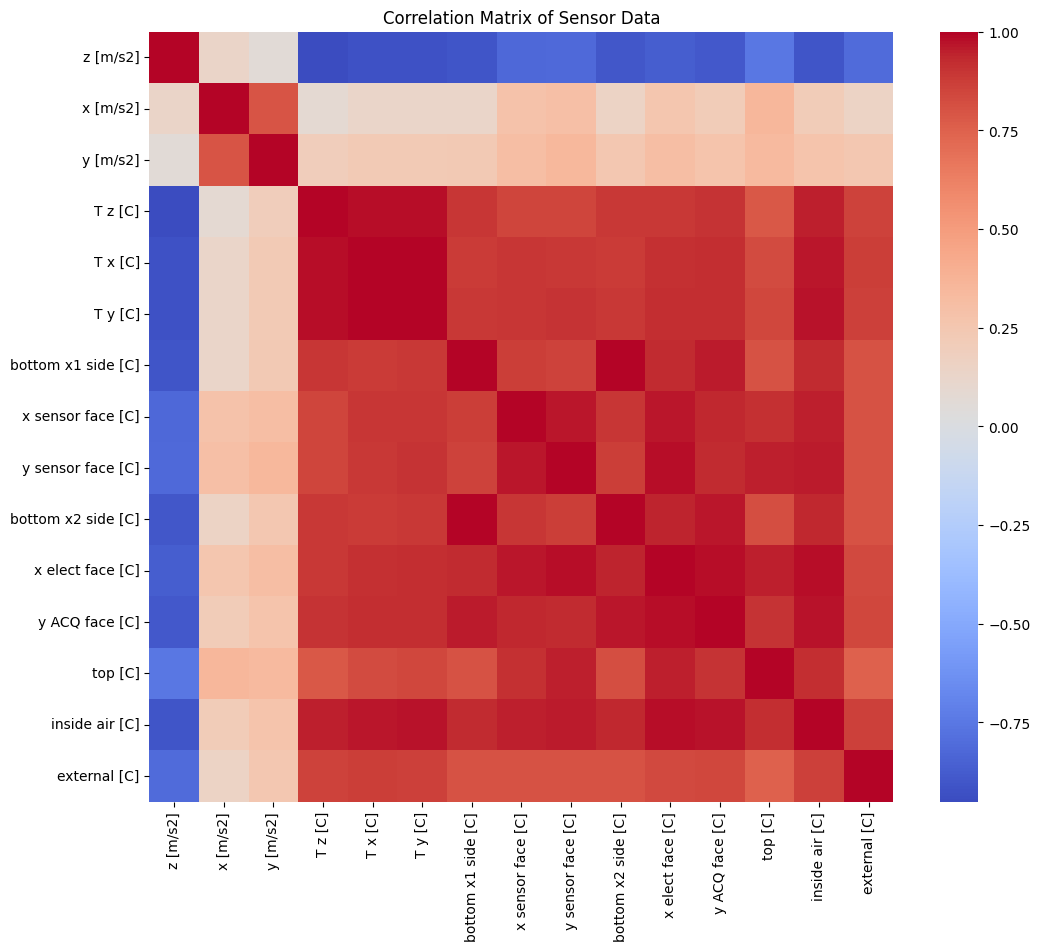

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
matrix_df = uninterrupted_df.drop(columns='Date')
corr_matrix = matrix_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Sensor Data")
plt.show()

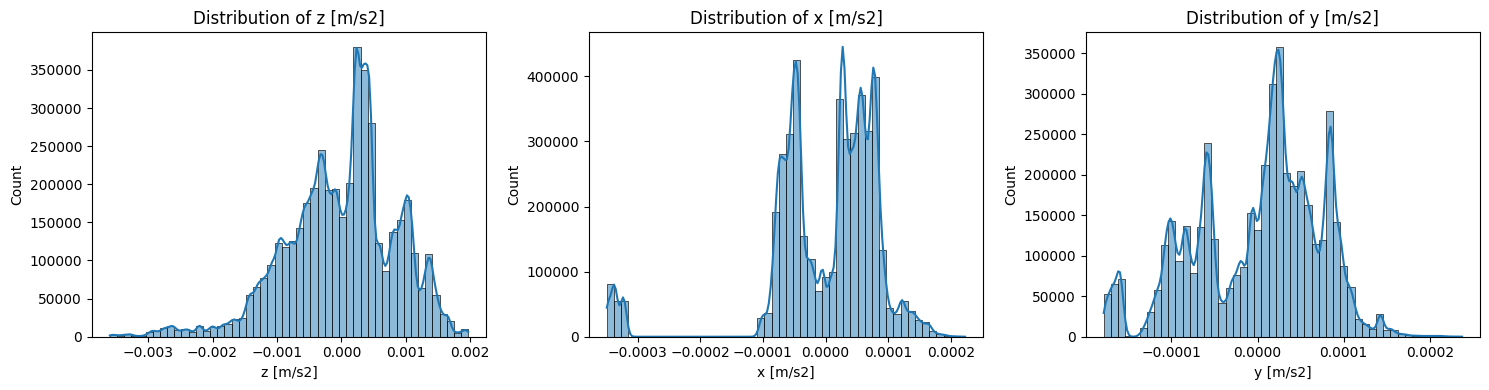

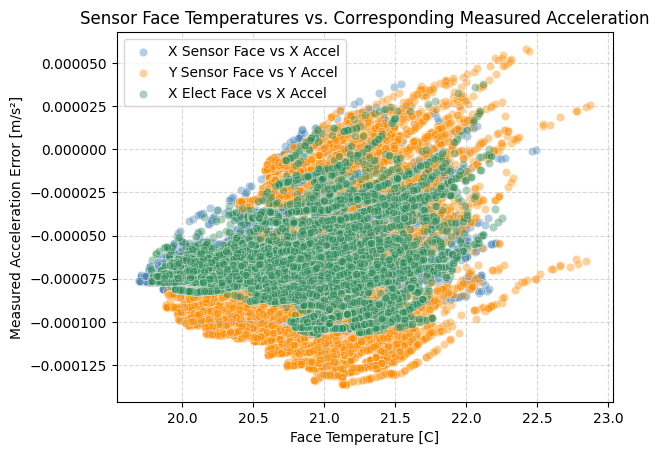

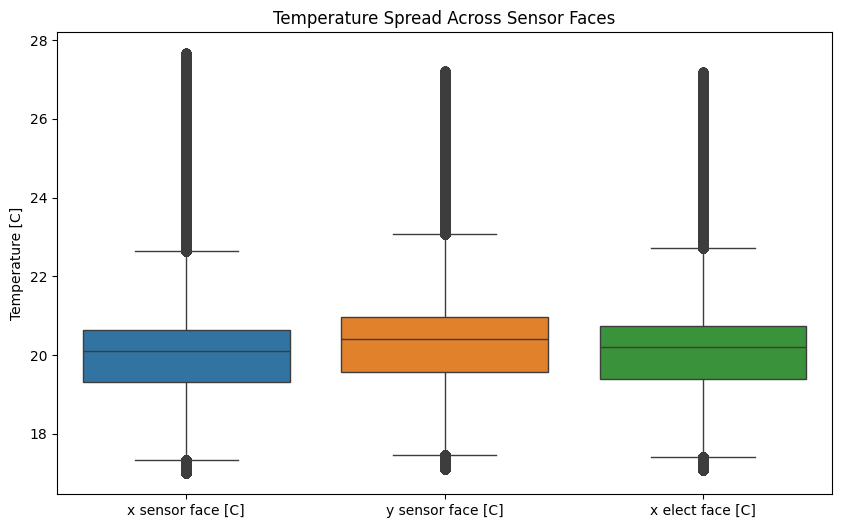

In [18]:
# Target distributions
target_cols = ['z [m/s2]', 'x [m/s2]', 'y [m/s2]']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(target_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Adjust sample size to prevent ValueError if uninterrupted_df is small
n_sample = min(10000, len(uninterrupted_df))
if n_sample > 0:
    df_sample = uninterrupted_df.sample(n=n_sample, random_state=42)
    sns.scatterplot(x='x sensor face [C]', y='x [m/s2]', data=df_sample,
                    color='steelblue', alpha=0.4, label='X Sensor Face vs X Accel')
    sns.scatterplot(x='y sensor face [C]', y='y [m/s2]', data=df_sample,
                    color='darkorange', alpha=0.4, label='Y Sensor Face vs Y Accel')
    sns.scatterplot(x='x elect face [C]', y='x [m/s2]', data=df_sample,
                    color='seagreen', alpha=0.4, label='X Elect Face vs X Accel')
    plt.title("Sensor Face Temperatures vs. Corresponding Measured Acceleration")
    plt.xlabel("Face Temperature [C]")
    plt.ylabel("Measured Acceleration Error [m/s²]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("uninterrupted_df is empty or too small for sampling.")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['x sensor face [C]', 'y sensor face [C]', 'x elect face [C]']])
plt.title("Temperature Spread Across Sensor Faces")
plt.ylabel("Temperature [C]")
plt.show()

In [19]:
uninterrupted_df["error_array"] = uninterrupted_df[[ "x [m/s2]", "y [m/s2]", "z [m/s2]"]].values.tolist()
uninterrupted_df["error_array"].head(10)

/tmp/ipykernel_4237/618095700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uninterrupted_df["error_array"] = uninterrupted_df[[ "x [m/s2]", "y [m/s2]", "z [m/s2]"]].values.tolist()


,error_array
1967042,"[1.523687473304808e-05, 2.655177236455821e-05,..."
1967043,"[1.4840056551229913e-05, 2.649495418274005e-05..."
1967044,"[1.4779556551229904e-05, 2.6426454182740016e-0..."
1967045,"[1.455005655122991e-05, 2.6461954182740026e-05..."
1967046,"[1.4421556551229905e-05, 2.629295418274004e-05..."
1967047,"[1.4431056551229914e-05, 2.6004454182740053e-0..."
1967048,"[1.4433556551229933e-05, 2.662845418274003e-05..."
1967049,"[1.486405655122992e-05, 2.6042954182740062e-05..."
1967050,"[1.416705655122991e-05, 2.660895418274003e-05,..."
1967051,"[1.3704556551229912e-05, 2.6328454182740055e-0..."


In [20]:
# Create lag features (exclude acceleration targets)
excluded_cols = ['Date', 'error_array', 'z [m/s2]', 'x [m/s2]', 'y [m/s2]']
feature_cols = [col for col in uninterrupted_df.columns if col not in excluded_cols]
print("Features being used (temperature and sensor data only):")
print(feature_cols)
X_df = uninterrupted_df[feature_cols].copy()
for lag in [1, 2, 5, 10]:
    for col in feature_cols:
        X_df[f'{col}_lag_{lag}'] = X_df[col].shift(lag)
X_df = X_df.dropna()
indices = X_df.index
y_array = uninterrupted_df.loc[indices, 'error_array'].values
y = np.array([arr for arr in y_array])
print(f"\nFeature shape after adding lags: {X_df.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of predictor features: {len(feature_cols)}")
print(f"Total features after lags: {X_df.shape[1]}")

Features being used (temperature and sensor data only):
['T z [C]', 'T x [C]', 'T y [C]', 'bottom x1 side [C]', 'x sensor face [C]', 'y sensor face [C]', 'bottom x2 side [C]', 'x elect face [C]', 'y ACQ face [C]', 'top [C]', 'inside air [C]', 'external [C]']

Feature shape after adding lags: (746255, 60)
Target shape: (746255, 3)
Number of predictor features: 12
Total features after lags: 60


In [21]:
import matplotlib.pyplot as plt
print("\n" + "="*60)
print("FEATURE-TARGET CORRELATION ANALYSIS")
print("="*60)
correlations = []
for feat in feature_cols:
    corr_x = np.corrcoef(uninterrupted_df.loc[indices, feat], y[:, 0])[0, 1]
    corr_y = np.corrcoef(uninterrupted_df.loc[indices, feat], y[:, 1])[0, 1]
    corr_z = np.corrcoef(uninterrupted_df.loc[indices, feat], y[:, 2])[0, 1]
    max_corr = max(abs(corr_x), abs(corr_y), abs(corr_z))
    correlations.append((feat, max_corr, corr_x, corr_y, corr_z))
correlations.sort(key=lambda x: abs(x[1]), reverse=True)
print("\nTop 10 features by correlation with targets:")
for i, (feat, max_c, cx, cy, cz) in enumerate(correlations[:10]):
    print(f"{i+1}. {feat:30s} | Max: {max_c:7.4f} | X: {cx:7.4f} Y: {cy:7.4f} Z: {cz:7.4f}")
weak_corr = sum(1 for _, max_c, _, _, _ in correlations if abs(max_c) < 0.1)
print(f"\nFeatures with |correlation| < 0.1: {weak_corr}/{len(feature_cols)}")
print("\n" + "="*60)
print("TARGET STATISTICS")
print("="*60)
print(f"X acceleration - Mean: {y[:, 0].mean():.2e}, Std: {y[:, 0].std():.2e}, Min: {y[:, 0].min():.2e}, Max: {y[:, 0].max():.2e}")
print(f"Y acceleration - Mean: {y[:, 1].mean():.2e}, Std: {y[:, 1].std():.2e}, Min: {y[:, 1].min():.2e}, Max: {y[:, 1].max():.2e}")
print(f"Z acceleration - Mean: {y[:, 2].mean():.2e}, Std: {y[:, 2].std():.2e}, Min: {y[:, 2].min():.2e}, Max: {y[:, 2].max():.2e}")


FEATURE-TARGET CORRELATION ANALYSIS

Top 10 features by correlation with targets:
1. T z [C]                        | Max:  0.9509 | X:  0.0852 Y:  0.1937 Z: -0.9509
2. T y [C]                        | Max:  0.9269 | X:  0.1293 Y:  0.2293 Z: -0.9269
3. T x [C]                        | Max:  0.9269 | X:  0.1262 Y:  0.2274 Z: -0.9269
4. bottom x1 side [C]             | Max:  0.9109 | X:  0.1305 Y:  0.2366 Z: -0.9109
5. inside air [C]                 | Max:  0.9088 | X:  0.2108 Y:  0.2758 Z: -0.9088
6. bottom x2 side [C]             | Max:  0.9036 | X:  0.1504 Y:  0.2487 Z: -0.9036
7. y ACQ face [C]                 | Max:  0.8947 | X:  0.2085 Y:  0.2755 Z: -0.8947
8. x elect face [C]               | Max:  0.8688 | X:  0.2593 Y:  0.3079 Z: -0.8688
9. x sensor face [C]              | Max:  0.8284 | X:  0.2793 Y:  0.3140 Z: -0.8284
10. y sensor face [C]              | Max:  0.8175 | X:  0.3054 Y:  0.3461 Z: -0.8175

Features with |correlation| < 0.1: 0/12

TARGET STATISTICS
X acceleration -

**Run GridSearchCV with a KNN as a baseline model**

In [22]:
# Create Train/Test Split
split_idx = int(len(X_df) * 0.8)
X_train = X_df.iloc[:split_idx].values
X_test = X_df.iloc[split_idx:].values
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"Train/Test Split:")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

Train/Test Split:
  Training set: (597004, 60)
  Test set: (149251, 60)


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

time_series_cv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsRegressor())
])

param_grid = {
    'pca__n_components': [0.80, 0.85, 0.90, 0.95, 0.99],
    'knn__n_neighbors': [3, 5, 7, 9, 11]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=time_series_cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

test_score = grid_search.score(X_test, y_test)
print(f"Test set R² score: {test_score:.4f}")

predictions = grid_search.predict(X_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best parameters: {'knn__n_neighbors': 11, 'pca__n_components': 0.99}
Best CV score: -3.1941
Test set R² score: -28.1517


**Alternative: Try Random Forest (often better for time-series regression)**

In [24]:
from sklearn.ensemble import RandomForestRegressor

time_series_cv = TimeSeriesSplit(n_splits=5)

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'pca__n_components': [0.80, 0.90, 0.95],
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [10, 20]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=time_series_cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

print(f"\nRandom Forest Results:")
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV score: {grid_search_rf.best_score_:.4f}")

test_score_rf = grid_search_rf.score(X_test, y_test)
print(f"Test set R² score: {test_score_rf:.4f}")

predictions_rf = grid_search_rf.predict(X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Random Forest Results:
Best parameters: {'pca__n_components': 0.95, 'rf__max_depth': 10, 'rf__n_estimators': 50}
Best CV score: -3.8133
Test set R² score: -19.6706


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("="*50)
print("MODEL COMPARISON")
print("="*50)

print(f"\nKNN Model:")
print(f"  Test R² Score: {test_score:.4f}")
mse_knn = mean_squared_error(y_test, predictions)
mae_knn = mean_absolute_error(y_test, predictions)
print(f"  Test MSE: {mse_knn:.6f}")
print(f"  Test MAE: {mae_knn:.6f}")

print(f"\nRandom Forest Model:")
print(f"  Test R² Score: {test_score_rf:.4f}")
mse_rf = mean_squared_error(y_test, predictions_rf)
mae_rf = mean_absolute_error(y_test, predictions_rf)
print(f"  Test MSE: {mse_rf:.6f}")
print(f"  Test MAE: {mae_rf:.6f}")

if test_score_rf > test_score:
    improvement = ((test_score_rf - test_score) / abs(test_score)) * 100 if test_score != 0 else float('inf')
    print(f"\n✓ Random Forest performs {improvement:.1f}% better on test set")

MODEL COMPARISON

KNN Model:
  Test R² Score: -28.1517
  Test MSE: 0.000000
  Test MAE: 0.000135

Random Forest Model:
  Test R² Score: -19.6706
  Test MSE: 0.000000
  Test MAE: 0.000105

✓ Random Forest performs 30.1% better on test set


**Better Approach: Autoregressive Model with Temperature Context**

The models are failing because temperature alone may not predict acceleration well. Use past acceleration values (autoregressive features) as the primary signal, with temperature as auxiliary context.

In [ ]:
# Create autoregressive features: use past acceleration values + temperature
ar_excluded = ['Date', 'error_array']
all_features = [col for col in uninterrupted_df.columns if col not in ar_excluded]

X_ar = uninterrupted_df[all_features].copy()

for lag in [1, 2, 5, 10]:
    for col in all_features:
        X_ar[f'{col}_lag_{lag}'] = X_ar[col].shift(lag)

X_ar = X_ar.dropna()
indices_ar = X_ar.index
y_ar = np.array([arr for arr in uninterrupted_df.loc[indices_ar, 'error_array'].values])

split_idx_ar = int(len(X_ar) * 0.8)
X_train_ar = X_ar.iloc[:split_idx_ar].values
X_test_ar = X_ar.iloc[split_idx_ar:].values
y_train_ar = y_ar[:split_idx_ar]
y_test_ar = y_ar[split_idx_ar:]

print(f"Autoregressive model:")
print(f"  Training set: {X_train_ar.shape}")
print(f"  Test set: {X_test_ar.shape}")
print(f"  Features: {X_ar.shape[1]}")

time_series_cv = TimeSeriesSplit(n_splits=5)

pipeline_ar = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid_ar = {
    'pca__n_components': [0.80, 0.90, 0.95],
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [15, 25]
}

grid_search_ar = GridSearchCV(
    pipeline_ar,
    param_grid_ar,
    cv=time_series_cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_ar.fit(X_train_ar, y_train_ar)

print(f"\nAutoregressive Random Forest Results:")
print(f"Best parameters: {grid_search_ar.best_params_}")
print(f"Best CV score: {grid_search_ar.best_score_:.4f}")

test_score_ar = grid_search_ar.score(X_test_ar, y_test_ar)
print(f"Test set R² score: {test_score_ar:.4f}")

predictions_ar = grid_search_ar.predict(X_test_ar)

mse_ar = mean_squared_error(y_test_ar, predictions_ar)
mae_ar = mean_absolute_error(y_test_ar, predictions_ar)
print(f"Test MSE: {mse_ar:.9f}")
print(f"Test MAE: {mae_ar:.9f}")

print("\n" + "="*60)
print("MODEL COMPARISON: Temperature-Only vs Autoregressive")
print("="*60)
print(f"Temperature-Only RF R²:    {test_score_rf:7.4f}")
print(f"Autoregressive RF R²:      {test_score_ar:7.4f}")
if test_score_ar > test_score_rf:
    improvement = ((test_score_ar - test_score_rf) / abs(test_score_rf)) * 100 if test_score_rf != 0 else float('inf')
    print(f"✓ Autoregressive is {improvement:.1f}% better")

Autoregressive model:
  Training set: (597004, 75)
  Test set: (149251, 75)
  Features: 75
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


**Feature Analysis and Improvement**

Something is not working well here... try to determine where the failure stems from in the existing features.

In [ ]:
print("\n" + "="*70)
print("PART 1: ACCELERATION TARGET ANALYSIS")
print("="*70)

accel_x = uninterrupted_df['x [m/s2]'].values
accel_y = uninterrupted_df['y [m/s2]'].values
accel_z = uninterrupted_df['z [m/s2]'].values

print("\nAcceleration Statistics:")
print(f"X-axis: Mean={accel_x.mean():.2e}, Std={accel_x.std():.2e}, Range=[{accel_x.min():.2e}, {accel_x.max():.2e}]")
print(f"Y-axis: Mean={accel_y.mean():.2e}, Std={accel_y.std():.2e}, Range=[{accel_y.min():.2e}, {accel_y.max():.2e}]")
print(f"Z-axis: Mean={accel_z.mean():.2e}, Std={accel_z.std():.2e}, Range=[{accel_z.min():.2e}, {accel_z.max():.2e}]")

print("\nAcceleration Autocorrelation:")
print(f"X: Corr(t, t+1) = {np.corrcoef(accel_x[:-1], accel_x[1:])[0,1]:.6f}")
print(f"Y: Corr(t, t+1) = {np.corrcoef(accel_y[:-1], accel_y[1:])[0,1]:.6f}")
print(f"Z: Corr(t, t+1) = {np.corrcoef(accel_z[:-1], accel_z[1:])[0,1]:.6f}")

print("\n" + "="*70)
print("PART 2: TEMPERATURE FEATURE ANALYSIS")
print("="*70)

temp_cols = [col for col in uninterrupted_df.columns if '[C]' in col]
print(f"\nTemperature sensors found: {len(temp_cols)}")
for col in temp_cols:
    temps = uninterrupted_df[col].values
    print(f"  {col:30s}: Mean={temps.mean():7.3f}°C, Std={temps.std():.4f}°C, Range=[{temps.min():.3f}, {temps.max():.3f}]")

print("\nTemperature Change Rates:")
for col in temp_cols:
    temps = uninterrupted_df[col].values
    diffs = np.diff(temps)
    print(f"  {col:30s}: dT/dt std = {diffs.std():.6f}°C/sec")

print("\n" + "="*70)
print("PART 3: CORRELATION ANALYSIS")
print("="*70)

print("\nCorrelations (Temperature → Acceleration):")
print(f"{'Sensor':<35} {'X Accel':>10} {'Y Accel':>10} {'Z Accel':>10} {'Max':>10}")
print("-" * 70)

correlations_by_sensor = {}
for col in temp_cols:
    temps = uninterrupted_df[col].values
    corr_x = np.corrcoef(temps, accel_x)[0, 1]
    corr_y = np.corrcoef(temps, accel_y)[0, 1]
    corr_z = np.corrcoef(temps, accel_z)[0, 1]
    max_corr = max(abs(corr_x), abs(corr_y), abs(corr_z))
    correlations_by_sensor[col] = (corr_x, corr_y, corr_z, max_corr)
    print(f"{col:<35} {corr_x:>10.5f} {corr_y:>10.5f} {corr_z:>10.5f} {max_corr:>10.5f}")

sorted_corrs = sorted(correlations_by_sensor.items(), key=lambda x: abs(x[1][3]), reverse=True)
print(f"\nStrongest temperature-acceleration correlations:")
for i, (sensor, (cx, cy, cz, max_c)) in enumerate(sorted_corrs[:5]):
    print(f"  {i+1}. {sensor}: {max_c:.5f}")

weak_temp_sensors = sum(1 for _, (_, _, _, mc) in correlations_by_sensor.items() if abs(mc) < 0.01)
print(f"\nTemperature sensors with |correlation| < 0.01: {weak_temp_sensors}/{len(temp_cols)}")

print("\n" + "="*70)
print("PART 4: INTER-SENSOR RELATIONSHIPS")
print("="*70)

print("\nTemperature Cross-Correlations:")
temp_corr_matrix = uninterrupted_df[temp_cols].corr()
off_diag_corrs = []
for i in range(len(temp_cols)):
    for j in range(i+1, len(temp_cols)):
        off_diag_corrs.append(temp_corr_matrix.iloc[i, j])

print(f"  Mean inter-sensor correlation: {np.mean(off_diag_corrs):.4f}")
print(f"  Range: [{min(off_diag_corrs):.4f}, {max(off_diag_corrs):.4f}]")
if np.mean(off_diag_corrs) > 0.95:
    print("  → Sensors are highly correlated (redundant)")
else:
    print("  → Sensors show variety")

print("\n" + "="*70)
print("PART 5: ACCELERATION VARIANCE BY TIME PERIOD")
print("="*70)

window = 1000
windows_x = []
for i in range(0, len(accel_x) - window, window):
    windows_x.append(accel_x[i:i+window].std())

print(f"\nAcceleration variance across {len(windows_x)} time windows:")
print(f"  Mean variance per window: {np.mean(windows_x):.2e}")
print(f"  Max variance in any window: {np.max(windows_x):.2e}")
print(f"  Min variance in any window: {np.min(windows_x):.2e}")

if np.mean(windows_x) < 1e-6:
    print("  ⚠ Acceleration is extremely stable")
else:
    print("  ✓ Acceleration shows meaningful variation")


In [ ]:
# Creating new features for the LSTM
# The goal is to make the model more temporally aware
print("\n" + "="*70)
print("PREPARING LSTM FEATURE SET")
print("="*70)

# Start with clean copy
df_lstm = uninterrupted_df.copy()
temp_cols = [col for col in df_lstm.columns if '[C]' in col]

print(f"\n1. Adding temperature change rates...")
for col in temp_cols:
    df_lstm[f'{col}_dT'] = df_lstm[col].diff().fillna(0)

print("2. Adding spatial statistics...")
df_lstm['temp_mean'] = df_lstm[temp_cols].mean(axis=1)
df_lstm['temp_std'] = df_lstm[temp_cols].std(axis=1)
df_lstm['temp_range'] = df_lstm[temp_cols].max(axis=1) - df_lstm[temp_cols].min(axis=1)

print("3. Adding sensor pair differences...")
df_lstm['x_sensor_diff'] = df_lstm['x sensor face [C]'] - df_lstm['x elect face [C]']
df_lstm['y_sensor_diff'] = df_lstm['y sensor face [C]'] - df_lstm['y ACQ face [C]']

print("4. Adding time features...")
df_lstm['datetime'] = pd.to_datetime(df_lstm['Date'], unit='ms') # Changed 's' to 'ms'
df_lstm['hour_of_day'] = df_lstm['datetime'].dt.hour
df_lstm['day_of_week'] = df_lstm['datetime'].dt.dayofweek
df_lstm['sin_hour'] = np.sin(2 * np.pi * df_lstm['hour_of_day'] / 24)
df_lstm['cos_hour'] = np.cos(2 * np.pi * df_lstm['hour_of_day'] / 24)

lstm_feature_cols = (
    temp_cols +  # 12 raw temperature sensors
    [f'{col}_dT' for col in temp_cols] +  # 12 temperature change rates
    ['temp_mean', 'temp_std', 'temp_range',  # 3 spatial stats
     'x_sensor_diff', 'y_sensor_diff',  # 2 sensor differences
     'hour_of_day', 'day_of_week', 'sin_hour', 'cos_hour']  # 4 time features
)

X_improved = df_lstm[lstm_feature_cols].copy()
X_improved = X_improved.fillna(0)

indices_improved = X_improved.index
y_improved = np.array([arr for arr in uninterrupted_df.loc[indices_improved, 'error_array'].values])

print(f"\nLSTM Feature Set Summary:")
print(f"  Total features: {len(lstm_feature_cols)}")
print(f"  Samples: {len(X_improved)}")
print(f"  Feature breakdown:")
print(f"    - Raw temperature sensors: 12")
print(f"    - Temperature change rates (dT/dt): 12")
print(f"    - Spatial statistics (mean, std, range): 3")
print(f"    - Sensor pair differences: 2")
print(f"    - Time features (hour, day, sin, cos): 4")
print(f"\n  Total: {X_improved.shape[1]} features × {len(X_improved)} samples")
print(f"\nNote: No lag features added (LSTM naturally learns temporal patterns from 30-timestep sequences)")

In [ ]:
!pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("LSTM BASELINE MODEL")
print("="*70)

sequence_length = 30

def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

scaler = MinMaxScaler()
X_improved_scaled = scaler.fit_transform(X_improved)

X_seq, y_seq = create_sequences(X_improved_scaled, y_improved, sequence_length)

print(f"\nSequence data shape:")
print(f"  X sequences: {X_seq.shape}  (samples, timesteps, features)")
print(f"  y targets: {y_seq.shape}  (samples, 3)")

split_idx_lstm = int(len(X_seq) * 0.8)
X_train_lstm = X_seq[:split_idx_lstm]
X_test_lstm = X_seq[split_idx_lstm:]
y_train_lstm = y_seq[:split_idx_lstm]
y_test_lstm = y_seq[split_idx_lstm:]

print(f"\nTrain/Test split:")
print(f"  Training: {X_train_lstm.shape[0]} sequences")
print(f"  Testing: {X_test_lstm.shape[0]} sequences")

print(f"\nBuilding LSTM model...")
model = keras.Sequential([
    layers.LSTM(64, activation='relu', input_shape=(sequence_length, X_improved.shape[1]), return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(3)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print(model.summary())

print(f"\nTraining LSTM...")
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nEvaluating...")
test_loss, test_mae = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
predictions_lstm = model.predict(X_test_lstm, verbose=0)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_lstm = r2_score(y_test_lstm, predictions_lstm)
mae_lstm = mean_absolute_error(y_test_lstm, predictions_lstm)
mse_lstm = mean_squared_error(y_test_lstm, predictions_lstm)

print(f"\nLSTM Results:")
print(f"  Test Loss (MSE): {test_loss:.9f}")
print(f"  Test MAE: {test_mae:.9f}")
print(f"  Test R² Score: {r2_lstm:.6f}")
print(f"  Test MAE (sklearn): {mae_lstm:.9f}")

In [ ]:
from tensorflow.keras import layers, Model

print("\n" + "="*70)
print("LSTM MODEL 1: MULTI-OUTPUT HEADS")
print("="*70)

# Input
sequence_input = layers.Input(shape=(sequence_length, X_improved.shape[1]))

# Shared LSTM
lstm_out = layers.LSTM(64, activation='relu', return_sequences=False)(sequence_input)
lstm_out = layers.Dropout(0.2)(lstm_out)
lstm_out = layers.Dense(32, activation='relu')(lstm_out)

# 3 output heads (one per dimension)
head_x = layers.Dense(1, name='accel_x')(lstm_out)
head_y = layers.Dense(1, name='accel_y')(lstm_out)
head_z = layers.Dense(1, name='accel_z')(lstm_out)

# Concatenate outputs
output = layers.Concatenate()([head_x, head_y, head_z])

model_multihead = Model(inputs=sequence_input, outputs=output)
model_multihead.compile(optimizer='adam', loss='mse', metrics=['mae'])

print(model_multihead.summary())

print("\nTraining multi-output heads LSTM...")
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_multihead = model_multihead.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTesting multi-output heads LSTM...")
test_loss_mh, test_mae_mh = model_multihead.evaluate(X_test_lstm, y_test_lstm, verbose=0)
predictions_mh = model_multihead.predict(X_test_lstm, verbose=0)

r2_mh = r2_score(y_test_lstm, predictions_mh)
mse_mh = mean_squared_error(y_test_lstm, predictions_mh)
mae_mh = mean_absolute_error(y_test_lstm, predictions_mh)

print(f"\nMulti-Output Heads LSTM Results:")
print(f"  Test Loss (MSE): {test_loss_mh:.9f}")
print(f"  Test R² Score: {r2_mh:.6f}")
print(f"  Test MAE: {mae_mh:.9f}")
print(f"  Test MSE: {mse_mh:.9f}")

In [ ]:
from tensorflow.keras import layers, Model

print("\n" + "="*70)
print("LSTM MODEL 2: MULTI-HEAD ATTENTION")
print("="*70)

sequence_input = layers.Input(shape=(sequence_length, X_improved.shape[1]))

# LSTM
lstm_out = layers.LSTM(64, activation='relu', return_sequences=True)(sequence_input)
lstm_out = layers.Dropout(0.2)(lstm_out)

# Multi-head attention
attention_out = layers.MultiHeadAttention(num_heads=4, key_dim=16)(lstm_out, lstm_out)
attention_out = layers.GlobalAveragePooling1D()(attention_out)

# Dense + output
dense = layers.Dense(32, activation='relu')(attention_out)

# 3 output heads
head_x = layers.Dense(1, name='accel_x')(dense)
head_y = layers.Dense(1, name='accel_y')(dense)
head_z = layers.Dense(1, name='accel_z')(dense)

output = layers.Concatenate()([head_x, head_y, head_z])

model_attention = Model(inputs=sequence_input, outputs=output)
model_attention.compile(optimizer='adam', loss='mse', metrics=['mae'])

print(model_attention.summary())

print("\nTraining multi-head attention LSTM...")
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_attention = model_attention.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTesting multi-head attention LSTM...")
test_loss_att, test_mae_att = model_attention.evaluate(X_test_lstm, y_test_lstm, verbose=0)
predictions_att = model_attention.predict(X_test_lstm, verbose=0)

r2_att = r2_score(y_test_lstm, predictions_att)
mse_att = mean_squared_error(y_test_lstm, predictions_att)
mae_att = mean_absolute_error(y_test_lstm, predictions_att)

print(f"\nMulti-Head Attention LSTM Results:")
print(f"  Test Loss (MSE): {test_loss_att:.9f}")
print(f"  Test R² Score: {r2_att:.6f}")
print(f"  Test MAE: {mae_att:.9f}")
print(f"  Test MSE: {mse_att:.9f}")

print("\n" + "="*70)
print("COMPARISON: Multi-Output Heads vs Multi-Head Attention")
print("="*70)
print(f"\n{'Model':<40} {'R² Score':>12} {'MAE':>12}")
print("-" * 65)
print(f"{'Multi-Output Heads LSTM':<40} {r2_mh:>12.6f} {mae_mh:>12.9f}")
print(f"{'Multi-Head Attention LSTM':<40} {r2_att:>12.6f} {mae_att:>12.9f}")

if r2_att > r2_mh:
    improvement = ((r2_att - r2_mh) / abs(r2_mh)) * 100 if r2_mh < 0 else r2_att - r2_mh
    print(f"\n✓ Multi-Head Attention performs better (Δ R² = {improvement:+.6f})")
else:
    improvement = ((r2_mh - r2_att) / abs(r2_att)) * 100 if r2_att < 0 else r2_mh - r2_att
    print(f"\n✓ Multi-Output Heads performs better (Δ R² = {improvement:+.6f})")

**Further Baseline Testing**

Imports and helper functions

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

RANDOM_STATE = 42

target_cols = ["x [m/s2]", "y [m/s2]", "z [m/s2]"]

temperature_cols = [
    "T z [C]",
    "T x [C]",
    "T y [C]",
    "bottom x1 side [C]",
    "x sensor face [C]",
    "y sensor face [C]",
    "bottom x2 side [C]",
    "x elect face [C]",
    "y ACQ face [C]",
    "top [C]",
    "inside air [C]",
    "external [C]"
]

Use this evaluation function to report results separately for each axis:

In [ ]:
def evaluate_predictions(model_name, y_true, y_pred):
    rows = []

    for i, axis in enumerate(["x", "y", "z"]):
        rows.append({
            "model": model_name,
            "axis": axis,
            "MAE": mean_absolute_error(y_true[:, i], y_pred[:, i]),
            "RMSE": np.sqrt(
                mean_squared_error(y_true[:, i], y_pred[:, i])
            ),
            "R2": r2_score(y_true[:, i], y_pred[:, i])
        })

    rows.append({
        "model": model_name,
        "axis": "macro_average",
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(
            y_true,
            y_pred,
            multioutput="uniform_average"
        )
    })

    return pd.DataFrame(rows)

**Create leakage-free features**

This cell creates:

Current temperature measurements

Lagged temperatures

Temperature-change rates

Spatial temperature summaries

Lagged acceleration values

The acceleration targets at time \(t\)

In [ ]:
model_df = uninterrupted_df.copy()
model_df = model_df.sort_values("Date").reset_index(drop=True)

# Temperature change rates
for col in temperature_cols:
    model_df[f"{col}_dT"] = model_df[col].diff()

# Spatial temperature summaries
model_df["temp_mean"] = model_df[temperature_cols].mean(axis=1)
model_df["temp_std"] = model_df[temperature_cols].std(axis=1)
model_df["temp_range"] = (
    model_df[temperature_cols].max(axis=1)
    - model_df[temperature_cols].min(axis=1)
)

# Physically meaningful temperature differences
model_df["x_sensor_diff"] = (
    model_df["x sensor face [C]"]
    - model_df["x elect face [C]"]
)

model_df["y_sensor_diff"] = (
    model_df["y sensor face [C]"]
    - model_df["y ACQ face [C]"]
)

# Temperature lags
temperature_lags = [1, 2, 5, 10, 30, 60]

for lag in temperature_lags:
    for col in temperature_cols:
        model_df[f"{col}_lag_{lag}"] = model_df[col].shift(lag)

# Acceleration lags
# Important: only shifted acceleration values are predictors.
acceleration_lags = [1, 2, 5, 10, 30, 60]

for lag in acceleration_lags:
    for col in target_cols:
        model_df[f"{col}_lag_{lag}"] = model_df[col].shift(lag)

Define the feature groups:

In [ ]:
temperature_feature_cols = (
    temperature_cols
    + [f"{col}_dT" for col in temperature_cols]
    + ["temp_mean", "temp_std", "temp_range"]
    + ["x_sensor_diff", "y_sensor_diff"]
    + [
        f"{col}_lag_{lag}"
        for lag in temperature_lags
        for col in temperature_cols
    ]
)

acceleration_lag_cols = [
    f"{col}_lag_{lag}"
    for lag in acceleration_lags
    for col in target_cols
]

combined_feature_cols = (
    temperature_feature_cols
    + acceleration_lag_cols
)

model_df = model_df.dropna(
    subset=combined_feature_cols + target_cols
).reset_index(drop=True)

print("Complete observations:", len(model_df))
print("Temperature features:", len(temperature_feature_cols))
print("Acceleration-lag features:", len(acceleration_lag_cols))
print("Combined features:", len(combined_feature_cols))

**Chronological train/test split**

Do not randomly shuffle this dataset.

In [ ]:
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train_temp = train_df[temperature_feature_cols]
X_test_temp = test_df[temperature_feature_cols]

X_train_ar = train_df[acceleration_lag_cols]
X_test_ar = test_df[acceleration_lag_cols]

X_train_combined = train_df[combined_feature_cols]
X_test_combined = test_df[combined_feature_cols]

y_train = train_df[target_cols].to_numpy()
y_test = test_df[target_cols].to_numpy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Test begins at:", test_df["Date"].iloc[0])

 **Mean baseline**

This predicts the training-set mean for every test observation.

In [ ]:
mean_prediction = np.tile(
    y_train.mean(axis=0),
    (len(y_test), 1)
)

mean_results = evaluate_predictions(
    "Training mean",
    y_test,
    mean_prediction
)

mean_results

**Persistence baseline**

Predict the current acceleration error using the immediately preceding observation:

In [ ]:
persistence_prediction = test_df[
    [f"{col}_lag_1" for col in target_cols]
].to_numpy()

persistence_results = evaluate_predictions(
    "Persistence: previous observation",
    y_test,
    persistence_prediction
)

persistence_results

**Rolling-mean baselines**

Create rolling averages using only previous observations:

In [ ]:
rolling_df = uninterrupted_df.copy()
rolling_df = rolling_df.sort_values("Date").reset_index(drop=True)

for window in [5, 10, 30, 60]:
    for col in target_cols:
        rolling_df[f"{col}_rolling_{window}"] = (
            rolling_df[col]
            .shift(1)
            .rolling(window=window)
            .mean()
        )

Match the rolling predictions to the test rows using Date:

In [ ]:
rolling_test = test_df[["Date"]].merge(
    rolling_df,
    on="Date",
    how="left"
)

rolling_results = []

for window in [5, 10, 30, 60]:
    pred_cols = [
        f"{col}_rolling_{window}"
        for col in target_cols
    ]

    y_pred = rolling_test[pred_cols].to_numpy()

    result = evaluate_predictions(
        f"Rolling mean: {window} seconds",
        y_test,
        y_pred
    )

    rolling_results.append(result)

rolling_results = pd.concat(
    rolling_results,
    ignore_index=True
)

rolling_results

**Drift baseline**

This extends the change between the two most recent observations:

In [ ]:
lag_1 = test_df[
    [f"{col}_lag_1" for col in target_cols]
].to_numpy()

lag_2 = test_df[
    [f"{col}_lag_2" for col in target_cols]
].to_numpy()

drift_prediction = lag_1 + (lag_1 - lag_2)

drift_results = evaluate_predictions(
    "One-step drift",
    y_test,
    drift_prediction
)

drift_results

**Ordinary linear regression**

First test temperature features alone:

In [ ]:
linear_temperature = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_temperature.fit(X_train_temp, y_train)

linear_temp_pred = linear_temperature.predict(X_test_temp)

linear_temp_results = evaluate_predictions(
    "Linear regression: temperature",
    y_test,
    linear_temp_pred
)

linear_temp_results

Then fit an autoregressive linear model using lagged acceleration only:

In [ ]:
linear_ar = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_ar.fit(X_train_ar, y_train)

linear_ar_pred = linear_ar.predict(X_test_ar)

linear_ar_results = evaluate_predictions(
    "Linear regression: acceleration lags",
    y_test,
    linear_ar_pred
)

linear_ar_results

Finally, combine lagged acceleration and thermal features:

In [ ]:
linear_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_combined.fit(X_train_combined, y_train)

linear_combined_pred = linear_combined.predict(
    X_test_combined
)

linear_combined_results = evaluate_predictions(
    "Linear regression: combined",
    y_test,
    linear_combined_pred
)

linear_combined_results

**Ridge regression with time-series cross-validation**

Ridge is one of the strongest candidates for the primary baseline because the temperature variables are highly correlated.

In [ ]:
time_series_cv = TimeSeriesSplit(n_splits=5)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0
    ]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_grid,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train_combined, y_train)

print("Best parameters:", ridge_search.best_params_)
print("Best CV MAE:", -ridge_search.best_score_)

ridge_pred = ridge_search.predict(X_test_combined)

ridge_results = evaluate_predictions(
    "Ridge: combined",
    y_test,
    ridge_pred
)

ridge_results

You should also run Ridge on the acceleration lags alone:

In [ ]:
ridge_ar_search = clone(ridge_search)
ridge_ar_search.fit(X_train_ar, y_train)

ridge_ar_pred = ridge_ar_search.predict(X_test_ar)

ridge_ar_results = evaluate_predictions(
    "Ridge: acceleration lags",
    y_test,
    ridge_ar_pred
)

ridge_ar_results

**Elastic Net**

ElasticNet fits one output at a time, so use MultiOutputRegressor.

In [ ]:
elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        MultiOutputRegressor(
            ElasticNet(
                max_iter=5000,
                random_state=RANDOM_STATE
            ),
            n_jobs=-1
        )
    )
])

elastic_grid = {
    "model__estimator__alpha": [
        1e-7,
        1e-6,
        1e-5,
        1e-4
    ],
    "model__estimator__l1_ratio": [
        0.1,
        0.5,
        0.9
    ]
}

elastic_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_grid,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1
)

elastic_search.fit(X_train_combined, y_train)

print("Best parameters:", elastic_search.best_params_)
print("Best CV MAE:", -elastic_search.best_score_)

elastic_pred = elastic_search.predict(
    X_test_combined
)

elastic_results = evaluate_predictions(
    "Elastic Net: combined",
    y_test,
    elastic_pred
)

elastic_results

**Partial least squares regression**

PLS is useful because the temperature predictors are strongly correlated.

In [ ]:
pls_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", PLSRegression(scale=False))
])

pls_grid = {
    "model__n_components": [2, 3, 5, 8, 10, 15]
}

pls_search = GridSearchCV(
    estimator=pls_pipeline,
    param_grid=pls_grid,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    verbose=1
)

pls_search.fit(X_train_temp, y_train)

print("Best parameters:", pls_search.best_params_)
print("Best CV MAE:", -pls_search.best_score_)

pls_pred = pls_search.predict(X_test_temp)

pls_results = evaluate_predictions(
    "PLS regression: temperature",
    y_test,
    pls_pred
)

pls_results

**Random forest without PCA**

Random forests generally do not require scaling or PCA.

Start with a reasonably small model because the dataset is large:

In [ ]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=20,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_forest.fit(
    X_train_combined,
    y_train
)

rf_pred = random_forest.predict(
    X_test_combined
)

rf_results = evaluate_predictions(
    "Random forest: combined",
    y_test,
    rf_pred
)

rf_results

A small tuning grid:

In [ ]:
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_leaf": [10, 50, 200],
    "max_features": [0.5, 0.8]
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=rf_grid,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train_combined, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

**Extra Trees regression**

In [ ]:
extra_trees = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=20,
    max_features=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

extra_trees.fit(
    X_train_combined,
    y_train
)

extra_trees_pred = extra_trees.predict(
    X_test_combined
)

extra_trees_results = evaluate_predictions(
    "Extra Trees: combined",
    y_test,
    extra_trees_pred
)

extra_trees_results

**Histogram gradient boosting**

Histogram gradient boosting does not directly support multiple targets, so wrap it with MultiOutputRegressor.

In [ ]:
hist_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=1.0,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    n_jobs=-1
)

hist_model.fit(
    X_train_combined,
    y_train
)

hist_pred = hist_model.predict(
    X_test_combined
)

hist_results = evaluate_predictions(
    "Histogram gradient boosting: combined",
    y_test,
    hist_pred
)

hist_results

Combine all results

In [ ]:
all_results = pd.concat([
    mean_results,
    persistence_results,
    rolling_results,
    drift_results,
    linear_temp_results,
    linear_ar_results,
    linear_combined_results,
    ridge_ar_results,
    ridge_results,
    elastic_results,
    pls_results,
    rf_results,
    extra_trees_results,
    hist_results
], ignore_index=True)

all_results

Display only the macro-average results:

In [ ]:
model_summary = (
    all_results[
        all_results["axis"] == "macro_average"
    ]
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_summary

Display per-axis performance:

In [ ]:
axis_results = (
    all_results[
        all_results["axis"].isin(["x", "y", "z"])
    ]
    .sort_values(["axis", "MAE"])
)

axis_results

**Plot the model comparison**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    data=model_summary,
    x="R2",
    y="model",
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Baseline Model Performance on Chronological Test Set")
plt.xlabel("Macro-Average Test R²")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

NameError: name 'model_summary' is not defined

<Figure size 1200x600 with 0 Axes>